In [1]:
import os
import sys

#  Set the working directory to the folder containing the top-level ultralytics package
os.chdir("/workspace")  # change to your workspace root where ultralytics folder exists
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [43]:
!git clone https://github.com/danielsyahputra/yolo-distiller.git
%cd yolo-distiller


Cloning into 'yolo-distiller'...
remote: Enumerating objects: 760, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 760 (delta 0), reused 0 (delta 0), pack-reused 757 (from 3)
Receiving objects: 100% (760/760), 1.68 MiB | 1.97 MiB/s, done.
Resolving deltas: 100% (185/185), done.
Updating files: 100% (595/595), done.
/workspace/yolo-distiller


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [3]:
#  Add the top-level ultralytics folder to Python path
os.chdir("/workspace/yolo-distiller")
print("Current working directory:", os.getcwd())

Current working directory: /workspace/yolo-distiller


In [4]:
from ultralytics import YOLO

import ultralytics
print(ultralytics.__file__)


/workspace/yolo-distiller/ultralytics/__init__.py


In [5]:
from ultralytics.nn import tasks
from ultralytics.models.yolo.model import YOLO

model = YOLO("bestv8nbase.pt")
model.info()


Model summary: 225 layers, 3,012,213 parameters, 0 gradients


(225, 3012213, 0, 0.0)

In [6]:
from ultralytics.nn import tasks
from ultralytics.models.yolo.model import YOLO

model = YOLO("bestv8lbase.pt")
model.info()


Model summary: 365 layers, 43,635,237 parameters, 0 gradients


(365, 43635237, 0, 0.0)

In [7]:
import os
print(os.getcwd())


/workspace/yolo-distiller


In [8]:
import torch
from ultralytics import YOLO

# --- Load model ---
model = YOLO("yolov8.yaml")  # your custom model
model.eval()  # evaluation mode

# --- Create dummy input ---
dummy_img = torch.randn(1, 3, 640, 640)  # batch_size=1, 3 channels, 640x640

# --- Forward pass through the model ---
with torch.no_grad():
    preds = model.model(dummy_img)  # list of outputs from YOLO layers

# --- Pick one output and compute a dummy EIoU loss ---
from ultralytics.utils.loss import BboxLoss
from ultralytics.utils.metrics import bbox_iou

# fake target boxes (x1,y1,x2,y2)
target_boxes = torch.tensor([[100, 100, 200, 200]], dtype=torch.float32)
pred_boxes = torch.tensor([[110, 110, 210, 210]], dtype=torch.float32)

bbox_loss_fn = BboxLoss()
# Mask & dummy target scores
fg_mask = torch.tensor([True])
target_scores = torch.tensor([[1.0]])
target_scores_sum = torch.tensor(1.0)

loss_iou, loss_dfl = bbox_loss_fn(
    pred_dist=torch.zeros(1, 16, 4),      # dummy DFL input
    pred_bboxes=pred_boxes,
    anchor_points=torch.zeros(1, 2),      # dummy anchors
    target_bboxes=target_boxes,
    target_scores=target_scores,
    target_scores_sum=target_scores_sum,
    fg_mask=fg_mask
)

print(f"[Sanity Check] loss_iou = {loss_iou.item()}, loss_dfl = {loss_dfl.item()}")


WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.3.204 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=yolov8.yaml, data=coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, c

train: Scanning /workspace/datasets/coco8/labels/train.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
val: Scanning /workspace/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]


Plotting labels to /workspace/yolo-distiller/runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000119, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /workspace/yolo-distiller/runs/detect/train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100     0.677G      3.395      5.414      4.359         21        640: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  9.52it/s]

                   all          4         17          0          0          0          0


...

                   all          4         17          0          0          0          0



100 epochs completed in 0.016 hours.
Optimizer stripped from /workspace/yolo-distiller/runs/detect/train/weights/last.pt, 6.5MB
Optimizer stripped from /workspace/yolo-distiller/runs/detect/train/weights/best.pt, 6.5MB

Validating /workspace/yolo-distiller/runs/detect/train/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8 summary (fused): 168 layers, 3,151,904 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 77.90it/s]

                   all          4         17          0          0          0          0


Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /workspace/yolo-distiller/runs/detect/train
[Sanity Check] loss_iou = 0.3275921940803528, loss_dfl = 2.7725887298583984


In [9]:
from ultralytics import YOLO
import time
import torch

# === Device setup ===
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# === Load teacher and student models ===
teacher_model = YOLO("bestv8lbase.pt")        # Teacher: already trained v8l with EIoU
student_model = YOLO("bestv8nbase.pt")        # Student: already trained v8n with EIoU

# === Training parameters ===
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
run_name = "yolov8nbase_eiouloss_KD_hyperpat20try"  # Run name for saving logs and weights
epochs = 1
imgsz = 1280
batch_size = 32
workers = 2
patience = 20
save_interval = 50
amp = True

# === Start KD training ===
print("\n=== STARTING KNOWLEDGE DISTILLATION TRAINING ===")
start_time = time.time()

student_model.train(
    data=dataset_yaml,
    teacher=teacher_model,
    distillation_loss="cwd",   # Use CWD for feature map distillation
    epochs=epochs,
    batch=batch_size,
    imgsz=imgsz,
    workers=workers,
    device=device,
    amp=amp,
    patience=patience,
    save_period=save_interval,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=1e-4,
    cos_lr=True,
    lrf=0.01,
    augment=True,
    name=run_name
)

total_time = time.time() - start_time
print(f"\nKD Training completed in {total_time/3600:.2f} hours")



=== STARTING KNOWLEDGE DISTILLATION TRAINING ===
New https://pypi.org/project/ultralytics/8.3.204 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=bestv8nbase.pt, data=/workspace/datasets/KITTI/kitti.yml, epochs=1, time=None, patience=20, batch=32, imgsz=1280, save=True, save_period=50, cache=False, device=cuda:0, workers=2, project=None, name=yolov8nbase_eiouloss_KD_hyperpat20try, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=Fals

train: Scanning /workspace/datasets/KITTI/labels/train.cache... 5984 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5984/5984 [00:00<?, ?it/s]
val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]


Plotting labels to /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 154 weight(decay=0.0), 168 weight(decay=0.0001), 166 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try
Starting training for 1 epochs...

WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.780738830566406. Dividing input by 255.
0: 640x640 (no detections), 27.6ms
Speed: 0.0ms preprocess, 27.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/187 [00:00<?, ?it/s]


0: 1280x1280 20 Cars, 11.3ms
1: 1280x1280 1 Car, 1 Van, 1 Person_sitting, 11.3ms
2: 1280x1280 9 Cars, 11.3ms
3: 1280x1280 8 Cars, 1 Van, 1 Person_sitting, 11.3ms
4: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 1 Cyclist, 11.3ms
5: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.3ms
6: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.3ms
7: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 1 Cyclist, 11.3ms
8: 1280x1280 8 Cars, 1 Van, 3 Pedestrians, 1 Person_sitting, 11.3ms
9: 1280x1280 10 Cars, 1 Van, 1 Person_sitting, 11.3ms
10: 1280x1280 2 Cars, 11.3ms
11: 1280x1280 3 Pedestrians, 11.3ms
12: 1280x1280 7 Cars, 11.3ms
13: 1280x1280 8 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
14: 1280x1280 9 Cars, 1 Pedestrian, 11.3ms
15: 1280x1280 3 Cars, 1 Person_sitting, 11.3ms
16: 1280x1280 16 Cars, 2 Vans, 1 Pedestrian, 11.3ms
17: 1280x1280 4 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
18: 1280x1280 4 Cars, 2 Trucks, 2 Trams, 11.3ms
19: 1280x1280 10 Cars, 1 Van, 1 T

...


0: 1280x1280 10 Cars, 1 Truck, 3 Pedestrians, 11.3ms
1: 1280x1280 3 Cars, 2 Vans, 7 Pedestrians, 5 Cyclists, 11.3ms
2: 1280x1280 7 Cars, 11.3ms
3: 1280x1280 3 Cars, 2 Cyclists, 11.3ms
4: 1280x1280 15 Cars, 1 Van, 11.3ms
5: 1280x1280 7 Cars, 1 Van, 1 Truck, 1 Cyclist, 11.3ms
6: 1280x1280 7 Cars, 11.3ms
7: 1280x1280 3 Cars, 11.3ms
8: 1280x1280 6 Cars, 11.3ms
9: 1280x1280 14 Cars, 1 Van, 1 Truck, 1 Cyclist, 11.3ms
10: 1280x1280 3 Cars, 2 Vans, 11.3ms
11: 1280x1280 15 Cars, 11.3ms
12: 1280x1280 7 Cars, 1 Van, 11.3ms
13: 1280x1280 6 Cars, 1 Van, 4 Pedestrians, 1 Cyclist, 11.3ms
14: 1280x1280 18 Cars, 4 Vans, 1 Pedestrian, 11.3ms
15: 1280x1280 4 Cars, 1 Van, 1 Pedestrian, 11.3ms
16: 1280x1280 2 Cars, 11.3ms
17: 1280x1280 2 Cars, 1 Van, 13 Pedestrians, 1 Person_sitting, 2 Cyclists, 11.3ms
18: 1280x1280 9 Cars, 4 Vans, 1 Truck, 8 Pedestrians, 2 Person_sittings, 2 Cyclists, 11.3ms
19: 1280x1280 3 Pedestrians, 1 Cyclist, 11.3ms
20: 1280x1280 6 Cars, 2 Vans, 11.3ms
21: 1280x1280 12 Cars, 1 Truck

        1/1      28.3G      0.623     0.3783     0.8776        360       1280: 100%|██████████| 187/187 [02:31<00:00,  1.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:06<00:00,  3.50it/s]


                   all       1497       7772      0.872      0.825       0.87      0.648

1 epochs completed in 0.046 hours.
Optimizer stripped from /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try/weights/last.pt, 6.3MB
Optimizer stripped from /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try/weights/best.pt, 6.3MB

Validating /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try/weights/best.pt...
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
Model summary (fused): 168 layers, 3,007,013 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:07<00:00,  3.16it/s]


                   all       1497       7772      0.889       0.83      0.891      0.658
                   Car       1333       5680      0.936      0.951      0.975      0.808
                   Van        425        563       0.94      0.918      0.956      0.776
                 Truck        190        198      0.942      0.859      0.933      0.791
            Pedestrian        357        896      0.825       0.78      0.847      0.497
        Person_sitting         13         30      0.751      0.633      0.704      0.405
               Cyclist        222        306      0.904      0.824      0.898      0.625
                  Tram         76         99      0.923      0.848      0.925      0.703
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20try

KD Training completed in 0.05 hours


In [ ]:
from ultralytics import YOLO
import time
import torch

# === Device setup ===
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# === Load teacher and student models ===
teacher_model = YOLO("bestv8lbase.pt")        # Teacher: already trained v8l with EIoU
student_model = YOLO("bestv8nbase.pt")        # Student: already trained v8n with EIoU

# === Training parameters ===
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
run_name = "yolov8nbase_eiouloss_KD_hyperpat20"  # Run name for saving logs and weights
epochs = 250
imgsz = 1280
batch_size = 32
workers = 2
patience = 20
save_interval = 50
amp = True

# === Start KD training ===
print("\n=== STARTING KNOWLEDGE DISTILLATION TRAINING ===")
start_time = time.time()

student_model.train(
    data=dataset_yaml,
    teacher=teacher_model,
    distillation_loss="cwd",   # Use CWD for feature map distillation
    epochs=epochs,
    batch=batch_size,
    imgsz=imgsz,
    workers=workers,
    device=device,
    amp=amp,
    patience=patience,
    save_period=save_interval,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=1e-4,
    cos_lr=True,
    lrf=0.01,
    augment=True,
    name=run_name
)

total_time = time.time() - start_time
print(f"\nKD Training completed in {total_time/3600:.2f} hours")



=== STARTING KNOWLEDGE DISTILLATION TRAINING ===
New https://pypi.org/project/ultralytics/8.3.204 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=bestv8nbase.pt, data=/workspace/datasets/KITTI/kitti.yml, epochs=250, time=None, patience=20, batch=32, imgsz=1280, save=True, save_period=50, cache=False, device=cuda:0, workers=2, project=None, name=yolov8nbase_eiouloss_KD_hyperpat20, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False

train: Scanning /workspace/datasets/KITTI/labels/train.cache... 5984 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5984/5984 [00:00<?, ?it/s]
val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]


Plotting labels to /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 154 weight(decay=0.0), 168 weight(decay=0.0001), 166 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to /workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20
Starting training for 250 epochs...

WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.780738830566406. Dividing input by 255.
0: 640x640 (no detections), 8.9ms
Speed: 0.0ms preprocess, 8.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/187 [00:00<?, ?it/s]


0: 1280x1280 20 Cars, 11.3ms
1: 1280x1280 1 Car, 1 Van, 1 Person_sitting, 11.3ms
2: 1280x1280 9 Cars, 11.3ms
3: 1280x1280 8 Cars, 1 Van, 1 Person_sitting, 11.3ms
4: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 1 Cyclist, 11.3ms
5: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.3ms
6: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.3ms
7: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 1 Cyclist, 11.3ms
8: 1280x1280 8 Cars, 1 Van, 3 Pedestrians, 1 Person_sitting, 11.3ms
9: 1280x1280 10 Cars, 1 Van, 1 Person_sitting, 11.3ms
10: 1280x1280 2 Cars, 11.3ms
11: 1280x1280 3 Pedestrians, 11.3ms
12: 1280x1280 7 Cars, 11.3ms
13: 1280x1280 8 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
14: 1280x1280 9 Cars, 1 Pedestrian, 11.3ms
15: 1280x1280 3 Cars, 1 Person_sitting, 11.3ms
16: 1280x1280 16 Cars, 2 Vans, 1 Pedestrian, 11.3ms
17: 1280x1280 4 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
18: 1280x1280 4 Cars, 2 Trucks, 2 Trams, 11.3ms
19: 1280x1280 10 Cars, 1 Van, 1 T

...

     58/250      28.6G     0.6182     0.3666     0.8811        286       1280:  29%|██▉       | 54/187 [00:44<01:48,  1.22it/s]


0: 1280x1280 15 Cars, 2 Vans, 1 Truck, 1 Pedestrian, 1 Cyclist, 11.3ms
1: 1280x1280 17 Cars, 3 Vans, 1 Pedestrian, 2 Cyclists, 11.3ms
2: 1280x1280 4 Cars, 1 Truck, 1 Pedestrian, 11.3ms
3: 1280x1280 3 Cars, 1 Pedestrian, 11.3ms
4: 1280x1280 6 Cars, 2 Pedestrians, 1 Tram, 11.3ms
5: 1280x1280 1 Van, 11.3ms
6: 1280x1280 4 Cars, 11.3ms
7: 1280x1280 14 Cars, 1 Pedestrian, 1 Cyclist, 1 Tram, 11.3ms
8: 1280x1280 10 Cars, 11.3ms
9: 1280x1280 2 Cars, 1 Pedestrian, 11.3ms
10: 1280x1280 9 Cars, 5 Vans, 11.3ms
11: 1280x1280 7 Cars, 1 Van, 1 Pedestrian, 1 Cyclist, 11.3ms
12: 1280x1280 4 Cars, 1 Van, 1 Truck, 1 Pedestrian, 11.3ms
13: 1280x1280 13 Cars, 1 Van, 1 Cyclist, 11.3ms
14: 1280x1280 4 Cars, 1 Cyclist, 11.3ms
15: 1280x1280 3 Cars, 1 Van, 1 Truck, 11.3ms
16: 1280x1280 6 Cars, 11.3ms
17: 1280x1280 10 Cars, 1 Van, 2 Pedestrians, 11.3ms
18: 1280x1280 3 Cars, 11.3ms
19: 1280x1280 4 Cars, 11.3ms
20: 1280x1280 5 Cars, 11.3ms
21: 1280x1280 2 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
22: 1280x1280 10 Cars

     58/250      28.6G     0.6173     0.3662      0.881        319       1280:  29%|██▉       | 55/187 [00:44<01:48,  1.22it/s]


0: 1280x1280 6 Cars, 1 Van, 1 Pedestrian, 11.3ms
1: 1280x1280 2 Cars, 1 Truck, 2 Cyclists, 11.3ms
2: 1280x1280 4 Cars, 4 Pedestrians, 11.3ms
3: 1280x1280 4 Cars, 2 Vans, 1 Cyclist, 11.3ms
4: 1280x1280 3 Cars, 1 Truck, 2 Pedestrians, 11.3ms
5: 1280x1280 8 Cars, 11.3ms
6: 1280x1280 3 Cars, 2 Pedestrians, 1 Cyclist, 11.3ms
7: 1280x1280 14 Cars, 2 Vans, 11.3ms
8: 1280x1280 8 Cars, 1 Van, 1 Pedestrian, 5 Cyclists, 2 Trams, 11.3ms
9: 1280x1280 2 Cars, 11.3ms
10: 1280x1280 2 Cars, 1 Van, 1 Truck, 10 Pedestrians, 11.3ms
11: 1280x1280 10 Cars, 2 Vans, 1 Truck, 11.3ms
12: 1280x1280 8 Cars, 1 Pedestrian, 11.3ms
13: 1280x1280 21 Cars, 4 Vans, 1 Truck, 1 Tram, 11.3ms
14: 1280x1280 6 Cars, 2 Pedestrians, 1 Cyclist, 11.3ms
15: 1280x1280 5 Cars, 2 Vans, 2 Trucks, 11.3ms
16: 1280x1280 2 Cars, 1 Van, 11.3ms
17: 1280x1280 3 Cars, 11.3ms
18: 1280x1280 9 Cars, 11.3ms
19: 1280x1280 6 Cars, 1 Van, 4 Pedestrians, 11.3ms
20: 1280x1280 10 Cars, 1 Van, 1 Cyclist, 11.3ms
21: 1280x1280 4 Cars, 1 Van, 1 Truck, 1 P

     58/250      28.6G     0.6176     0.3666     0.8813        302       1280:  30%|██▉       | 56/187 [00:45<01:47,  1.22it/s]

In [11]:
import sys
from pathlib import Path
import torch
import time
from ultralytics import YOLO  # Use YOLOv8's interface

weights = "runs/detect/yolov8nbase_eiouloss_KD_hyperpat20/weights/best.pt"
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
results_dir = "/workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill"

# ------------------- Device -------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ------------------- Load model -------------------
model = YOLO(weights)  # Load the model using YOLOv8
params = sum(p.numel() for p in model.model.parameters())
params_mb = params * 4 / (1024**2)  # float32 -> 4 bytes
model_size_mb = Path(weights).stat().st_size / 1024**2  # file size in MB

print(f"Model size (file): {model_size_mb:.2f} MB")
print(f"Model parameters: {params_mb:.2f} MB")

# ------------------- FPS Measurement -------------------
dummy_input = torch.randn(1, 3, 1280, 1280).to(device) / 255.0  # Normalize the dummy input
# Warm-up
for _ in range(5):
    _ = model(dummy_input)  # Use the model directly for inference

n_runs = 50
start_time = time.time()
for _ in range(n_runs):
    _ = model(dummy_input)  # Use the model directly for inference
end_time = time.time()

fps = n_runs / (end_time - start_time)
print(f"Inference FPS (1280x1280): {fps:.2f}")

# ------------------- Run Validation -------------------
print("\nRunning YOLOv8 validation...")
start_val_time = time.time()
model.val(
    data=dataset_yaml,  # Validation dataset
    imgsz=1280,          # Image size
    batch=64,            # Corrected batch size argument
    device=device,       # Device
    project=results_dir, # Results directory
    name="eval_metrics", # Name for saved results
    save_json=True,      # Save results as JSON
    exist_ok=True,       # Overwrite if results directory exists
    verbose=True         # Show verbose output
)
end_val_time = time.time()

val_time = end_val_time - start_val_time
print(f"Validation time: {val_time:.2f} seconds")
print(f"Validation results saved to {results_dir}")


Model size (file): 6.00 MB
Model parameters: 11.49 MB

0: 1280x1280 (no detections), 4.9ms
Speed: 0.0ms preprocess, 4.9ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 2.6ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.0ms
Speed: 0.0ms preprocess, 5.0ms inference, 1.8ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.0ms
Speed: 0.0ms preprocess, 5.0ms inference, 1.3ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 4.9ms
Speed: 0.0ms preprocess, 4.9ms inference, 1.3ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.0ms
Speed: 0.0ms preprocess, 5.0ms inference, 1.5ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.0ms
Speed: 0.0ms preprocess, 5.0ms inference, 1.3ms postprocess per image at shape (1, 3, 1280, 1280)



val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:08<00:00,  2.74it/s]


                   all       1497       7772      0.914      0.915      0.937      0.764
                   Car       1333       5680      0.959      0.965      0.987       0.88
                   Van        425        563      0.952      0.956      0.982      0.866
                 Truck        190        198      0.974      0.941      0.973      0.881
            Pedestrian        357        896      0.933       0.83      0.907      0.572
        Person_sitting         13         30      0.751      0.867      0.817      0.589
               Cyclist        222        306      0.917      0.895      0.944      0.741
                  Tram         76         99      0.914      0.949      0.951      0.816
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill/eval_metrics/predictions.json...
Results saved to /workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill/eval_metrics
Validation time: 12.66 secon

In [12]:
import numpy as np
import pandas as pd

# -----------------------------
# CONFIGURATION
# -----------------------------
class_names = ["Car", "Van", "Truck", "Pedestrian", "Person_sitting", "Cyclist", "Tram"]
num_classes = len(class_names)

# -----------------------------
# CONFUSION MATRIX (predicted rows x true cols)
# -----------------------------
conf_matrix = np.array([
    [5536, 7, 0, 0, 0, 2, 0, 358],
    [0, 539, 1, 0, 0, 0, 0, 39],
    [0, 1, 186, 0, 0, 0, 0, 8],
    [0, 0, 0, 787, 0, 2, 0, 137],
    [0, 0, 0, 0, 26, 0, 0, 13],
    [0, 0, 0, 1, 1, 281, 0, 54],
    [0, 0, 0, 0, 0, 0, 94, 13],
    [144, 16, 11, 108, 3, 21, 5, 0]
])

# -----------------------------
# PER-CLASS LOG
# -----------------------------
per_class_precision = [0.959, 0.952, 0.974, 0.933, 0.751, 0.917, 0.914]  
per_class_recall =    [0.965, 0.956, 0.941, 0.83, 0.867, 0.895, 0.949]  
per_class_map50 = [0.987, 0.982, 0.973, 0.907, 0.817, 0.944, 0.951]
per_class_map5095 = [0.88, 0.866, 0.881, 0.572, 0.589, 0.741, 0.816]

# -----------------------------
# COMPUTE METRICS
# -----------------------------
metrics_data = []
total_samples = np.sum(conf_matrix)

for i, cname in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[i, :]) - TP
    FN = np.sum(conf_matrix[:, i]) - TP
    TN = total_samples - (TP + FP + FN)

    #Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    #Recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    Precision = per_class_precision[i] 
    Recall = per_class_recall[i]        
    F1 = 2 * Precision * Recall / (Precision + Recall) if (Precision + Recall) > 0 else 0
    Accuracy = (TP + TN) / total_samples if total_samples > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

    metrics_data.append({
        "Class": cname,
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
        "Precision": round(per_class_precision[i], 4),
        "Recall": round(per_class_recall[i], 4),
        "F1 Score": round(F1, 4),
        "Accuracy": round(Accuracy, 4),
        "FPR": round(FPR, 4),
        "FNR": round(FNR, 4),
        "mAP@0.5": per_class_map50[i],
        "mAP@0.5:0.95": per_class_map5095[i]
    })

# -----------------------------
# OVERALL ROW
# -----------------------------
TP_total = sum(row["TP"] for row in metrics_data)
FP_total = sum(row["FP"] for row in metrics_data)
FN_total = sum(row["FN"] for row in metrics_data)
TN_total = sum(row["TN"] for row in metrics_data)

overall = {
    "Class": "Overall",
    "TP": TP_total,
    "FP": FP_total,
    "FN": FN_total,
    "TN": TN_total,
    "Precision": np.mean([row["Precision"] for row in metrics_data]),
    "Recall": np.mean([row["Recall"] for row in metrics_data]),
    "F1 Score": np.mean([row["F1 Score"] for row in metrics_data]),
    "Accuracy": np.mean([row["Accuracy"] for row in metrics_data]),
    "FPR": np.mean([row["FPR"] for row in metrics_data]),
    "FNR": np.mean([row["FNR"] for row in metrics_data]),
    "mAP@0.5": np.mean([row["mAP@0.5"] for row in metrics_data]),
    "mAP@0.5:0.95": np.mean([row["mAP@0.5:0.95"] for row in metrics_data])
}

metrics_data.append(overall)

# -----------------------------
# SAVE TO CSV
# -----------------------------
df_metrics = pd.DataFrame(metrics_data)
df_metrics.to_csv("yolov8nbaseSGD_eioulossinKD_hyperpat20_distill_metrics.csv", index=False)
print(df_metrics)


            Class    TP   FP   FN     TN  Precision    Recall  F1 Score  \
0             Car  5536  367  144   2347   0.959000  0.965000  0.962000   
1             Van   539   40   24   7791   0.952000  0.956000  0.954000   
2           Truck   186    9   12   8187   0.974000  0.941000  0.957200   
3      Pedestrian   787  139  109   7359   0.933000  0.830000  0.878500   
4  Person_sitting    26   13    4   8351   0.751000  0.867000  0.804800   
5         Cyclist   281   56   25   8032   0.917000  0.895000  0.905900   
6            Tram    94   13    5   8282   0.914000  0.949000  0.931200   
7         Overall  7449  637  323  50349   0.914286  0.914714  0.913371   

   Accuracy       FPR       FNR   mAP@0.5  mAP@0.5:0.95  
0  0.939100  0.135200  0.025400  0.987000      0.880000  
1  0.992400  0.005100  0.042600  0.982000      0.866000  
2  0.997500  0.001100  0.060600  0.973000      0.881000  
3  0.970500  0.018500  0.121700  0.907000      0.572000  
4  0.998000  0.001600  0.133300  0


image 1/1 /workspace/000007.png: 416x1280 4 Cars, 2 Trams, 34.0ms
Speed: 2.5ms preprocess, 34.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 1280)


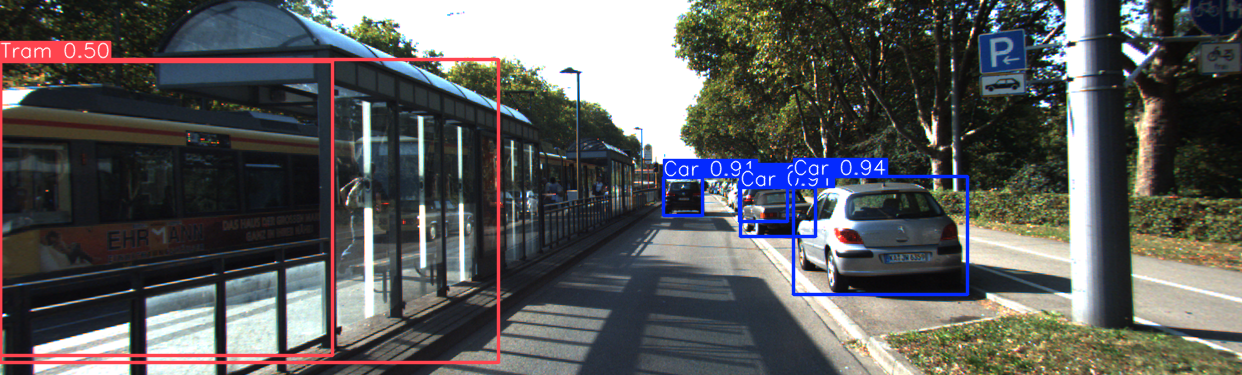

In [13]:
from ultralytics import YOLO

# Try loading and running inference with the trained model
model = YOLO("runs/detect/yolov8nbase_eiouloss_KD_hyperpat20/weights/best.pt")  # path to your trained model
results = model.predict("/workspace/000007.png")  # use any sample image
results[0].show()


In [14]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = '/workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill'
zip_file_path = '/workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/yolov8nbase_eiouloss_KD_hyperpat20_distill.zip'

In [15]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = 'runs/detect/yolov8nbase_eiouloss_KD_hyperpat20'
zip_file_path = 'runs/detect/yolov8nbase_eiouloss_KD_hyperpat20.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/yolo-distiller/runs/detect/yolov8nbase_eiouloss_KD_hyperpat20.zip'